In [1]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.structural import UnobservedComponents
from sklearn.preprocessing import StandardScaler, MinMaxScaler, KBinsDiscretizer

## Comprensión de los datos

Dimensión (filas, columnas): (22630, 16)

Columnas numéricas: ['CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM25', 'PRS', 'RAINF', 'RH', 'SO2', 'SR', 'TOUT', 'WDR', 'WDV', 'WSR']

Columnas categóricas: []

Duplicados detectados: 0

Aproximación de frecuencia temporal: 0 days 01:00:00

Faltantes por columna (top):
WDR     14108
WDV      9052
PM25     2735
CO       1312
O3       1252
PRS       917
SO2       811
NO        774
NO2       751
NOX       751
dtype: int64


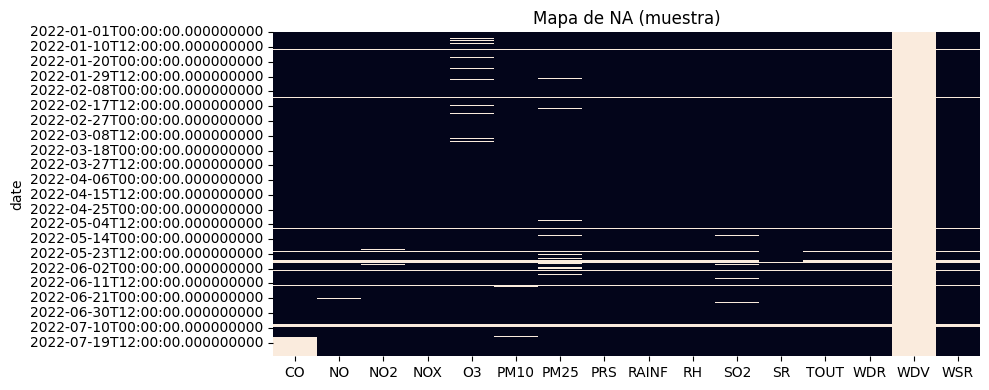

,negativos,mayores_3x_p99(>10.89),mayores_3x_p99(>442.47),mayores_3x_p99(>162.97),mayores_3x_p99(>575.50),mayores_3x_p99(>291.00),mayores_3x_p99(>750.45),mayores_3x_p99(>264.00),mayores_3x_p99(>2134.20),mayores_3x_p99(>0.09),mayores_3x_p99(>276.00),mayores_3x_p99(>51.30),mayores_3x_p99(>2.41),mayores_3x_p99(>110.28),mayores_3x_p99(>1035.00),mayores_3x_p99(>1038.00),mayores_3x_p99(>58.80)
CO,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NO,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NO2,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NOX,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
O3,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PM10,0.0,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PM25,0.0,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PRS,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RAINF,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RH,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df = pd.read_excel("../MA2003B/data_limpia/suroeste.xlsx")

df.columns = [re.sub(r'[^0-9a-zA-Z_]+', '', c) for c in df.columns]

date_col_candidates = [c for c in df.columns if re.search(r'date|fecha|time|datetime', c)]
date_col = date_col_candidates[0] if date_col_candidates else df.columns[0]

station_candidates = [c for c in df.columns if re.search(r'estacion|station|site|sitie|ubic|planta', c)]
station_col = station_candidates[0] if station_candidates else None

df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

df = df.sort_values(date_col).reset_index(drop=True).set_index(date_col)

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]

print("Dimensión (filas, columnas):", df.shape)
print("\nColumnas numéricas:", num_cols)
print("\nColumnas categóricas:", cat_cols)

dict_rows = []
for c in df.columns:
    s = df[c]
    row = {
        "columna": c,
        "tipo": str(s.dtype),
        "nulos": int(s.isna().sum()),
        "%nulos": round(100*s.isna().mean(), 2),
    }
    if s.dtype == "O" or s.dtype.name == "category":
        uniq = s.nunique(dropna=True)
        row["distintos"] = int(uniq)
        row["muestra_valores"] = ", ".join(map(str, s.dropna().unique()[:8])) + ("..." if uniq>8 else "")
    else:
        row["min"] = s.min()
        row["p1"] = s.quantile(0.01)
        row["p50"] = s.median()
        row["p99"] = s.quantile(0.99)
        row["max"] = s.max()
    dict_rows.append(row)
data_dictionary = pd.DataFrame(dict_rows).sort_values("columna")
data_dictionary

if station_col:
    dups = df.reset_index().duplicated(subset=[date_col, station_col]).sum()
else:
    dups = df.reset_index().duplicated(subset=[date_col]).sum()
print(f"\nDuplicados detectados: {dups}")

def infer_freq(s):
    d = s.index.to_series().diff().dropna()
    return d.mode().iloc[0] if not d.empty else pd.Timedelta("0s")

freq_guess = infer_freq(df)
print("\nAproximación de frecuencia temporal:", freq_guess)

print("\nFaltantes por columna (top):")
print(df[num_cols].isna().sum().sort_values(ascending=False).head(10))

sample = df[num_cols].iloc[:5000]
plt.figure(figsize=(10,4))
sns.heatmap(sample.isna(), cbar=False)
plt.title("Mapa de NA (muestra)")
plt.tight_layout(); plt.show()

bad_ranges = {}
for c in num_cols:
    s = df[c]
    neg = int((s < 0).sum())
    hi = s.quantile(0.99) * 3  
    big = int((s > hi).sum())
    bad_ranges[c] = {"negativos":neg, f"mayores_3x_p99(>{hi:.2f})":big}
pd.DataFrame(bad_ranges).T


## Preparación de los datos

In [3]:
df_prep = df.copy()
df_prep = df_prep[~df_prep.index.isna()]
keep_cols = [c for c in num_cols if df_prep[c].isna().mean() < 0.80]
df_prep = df_prep[cat_cols + keep_cols]

print("Columnas incluidas (por cobertura):", keep_cols)
target_cols = keep_cols

if station_col:
    df_prep = (df_prep.reset_index()
                        .drop_duplicates(subset=[date_col, station_col])
                        .set_index(date_col))
else:
    df_prep = (df_prep.reset_index()
                        .drop_duplicates(subset=[date_col])
                        .set_index(date_col))

def clip_by_quantiles(g, cols, q_low=0.01, q_hi=0.99):
    for c in cols:
        s = g[c]
        lo, hi = s.quantile(q_low), s.quantile(q_hi)
        g[c] = s.clip(lower=max(lo, 0), upper=hi)
    return g

if station_col:
    df_prep = df_prep.groupby(station_col, group_keys=False).apply(clip_by_quantiles, cols=target_cols)
else:
    df_prep = clip_by_quantiles(df_prep, cols=target_cols)

def hampel(series, window=7*24, n_sigmas=3.0):
    s = series.copy()
    k = int(window)
    if k < 3 or s.isna().all():
        return s
    med = s.rolling(k, center=True, min_periods=max(3, k//3)).median()
    mad = (s - med).abs().rolling(k, center=True, min_periods=max(3, k//3)).median() * 1.4826
    mask = (mad > 0) & ((s - med).abs() > n_sigmas*mad)
    s[mask] = np.nan  
    return s

hours = max(int(pd.Timedelta(freq_guess).total_seconds()//3600), 1)
win = 7*24//hours 
for c in target_cols:
    if station_col:
        df_prep[c] = df_prep.groupby(station_col, group_keys=False)[c].apply(lambda s: hampel(s, window=win))
    else:
        df_prep[c] = hampel(df_prep[c], window=win)

def impute_series(ts, freq='infer', small_gap=6, method='kalman'):
    s = ts.copy()
    s_interp = s.interpolate(method='time', limit=small_gap, limit_direction='both')

    if method == 'none':
        return s_interp

    if freq == 'infer':
        period = 24 if hours==1 else (7 if hours>=24 else 24)  
    else:
        period = 24

    try:
        mod = UnobservedComponents(s_interp, level='local linear trend', seasonal=period if period>=2 else None)
        res = mod.fit(disp=False)
        fitted = res.predict(start=s.index.min(), end=s.index.max())
        s_interp[s.isna()] = fitted[s.isna()]
    except Exception:
        try:
            stl = STL(s_interp, period=max(2, period), robust=True).fit()
            resid = s_interp - stl.seasonal
            resid = resid.interpolate(method='time', limit_direction='both')
            s_interp[s.isna()] = (resid + stl.seasonal)[s.isna()]
        except Exception:
            s_interp = s_interp.interpolate(method='time', limit_direction='both')

    return s_interp

# Imputación por estación y columna
for c in target_cols:
    flag = f"{c}_imputed"
    if station_col:
        def _imp(g):
            orig_na = g[c].isna()
            g[c] = impute_series(g[c], freq='infer', small_gap=6, method='kalman')
            g[flag] = orig_na & g[c].notna()
            return g
        df_prep = df_prep.groupby(station_col, group_keys=False).apply(_imp)
    else:
        orig_na = df_prep[c].isna()
        df_prep[c] = impute_series(df_prep[c], freq='infer', small_gap=6, method='kalman')
        df_prep[flag] = orig_na & df_prep[c].notna()



Columnas incluidas (por cobertura): ['CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM25', 'PRS', 'RAINF', 'RH', 'SO2', 'SR', 'TOUT', 'WDR', 'WDV', 'WSR']


c:\Users\anduj\Documents\Tecnologico_de_monterrey\Métodos multivariados\MA2003B\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\anduj\Documents\Tecnologico_de_monterrey\Métodos multivariados\MA2003B\venv\Lib\site-packages\statsmodels\tsa\filters\hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)
c:\Users\anduj\Documents\Tecnologico_de_monterrey\Métodos multivariados\MA2003B\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\anduj\Documents\Tecnologico_de_monterrey\Métodos multivariados\MA2003B\venv\Lib\sit

## Gráficos:

In [4]:
sns.set(context="talk", style="whitegrid")
pollutants = target_cols[:]  # alias
rolling_win = 24 if hours == 1 else (7 if hours >= 24 else 24)  

### Cobertura residual y porcentaje imputado por variable

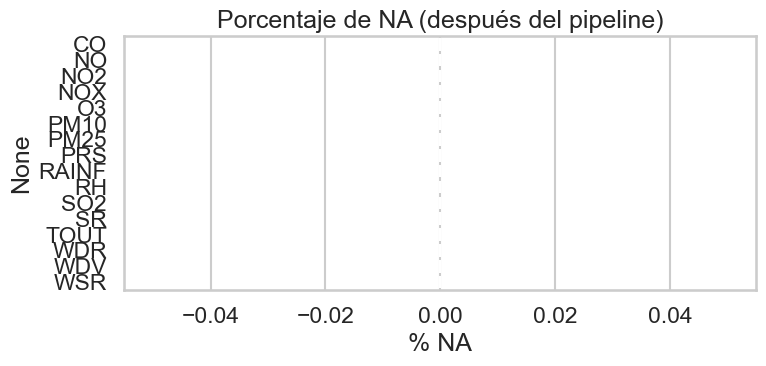

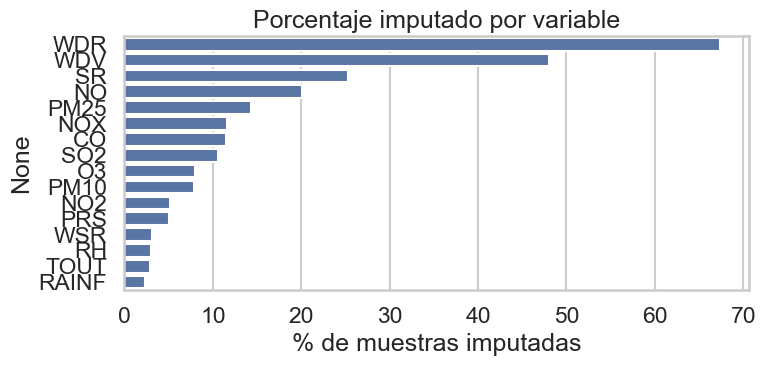

In [5]:

na_pct = df_prep[pollutants].isna().mean().sort_values(ascending=False) * 100
plt.figure(figsize=(8,4))
sns.barplot(x=na_pct.values, y=na_pct.index)
plt.xlabel("% NA"); plt.title("Porcentaje de NA (después del pipeline)")
plt.tight_layout(); plt.show()

imp_cols = [f"{c}_imputed" for c in pollutants if f"{c}_imputed" in df_prep.columns]
if imp_cols:
    imp_pct = df_prep[imp_cols].mean().rename(lambda x: x.replace("_imputed","")).sort_values(ascending=False)*100
    plt.figure(figsize=(8,4))
    sns.barplot(x=imp_pct.values, y=imp_pct.index)
    plt.xlabel("% de muestras imputadas"); plt.title("Porcentaje imputado por variable")
    plt.tight_layout(); plt.show()


### Series de tiempo

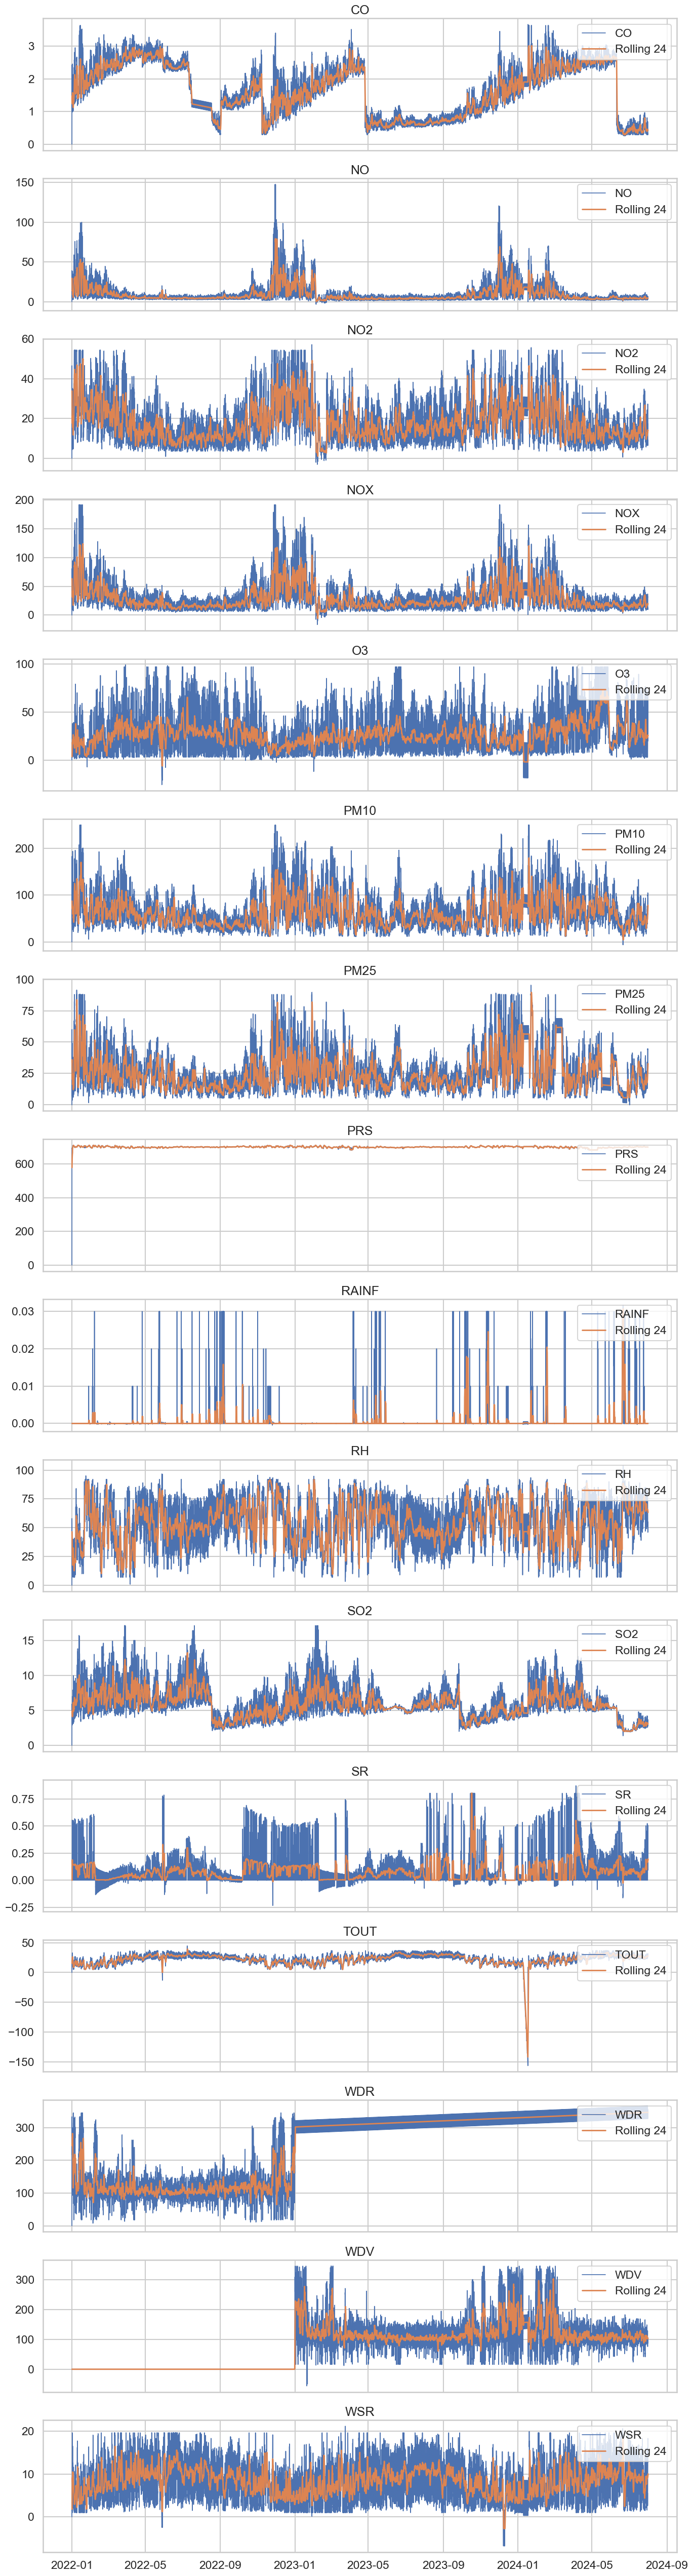

In [6]:
fig, axes = plt.subplots(len(pollutants), 1, figsize=(14, 3.2*len(pollutants)), sharex=True)
axes = np.atleast_1d(axes)
for ax, c in zip(axes, pollutants):
    ax.plot(df_prep.index, df_prep[c], lw=1.2, label=c.upper())
    ax.plot(df_prep.index, df_prep[c].rolling(rolling_win, min_periods=max(2, rolling_win//4)).mean(),
            lw=2, label=f"Rolling {rolling_win}")
    ax.set_title(c.upper()); ax.legend(loc="upper right")
plt.tight_layout(); plt.show()

### En el año:

In [7]:
sns.set(context="talk", style="whitegrid")

pollutants = target_cols[:] 
rolling_win = 24 if hours == 1 else (7 if hours >= 24 else 24)  
resample_rule_year = None     
resample_rule_month = None   
if station_col:
    estaciones = df_prep[station_col].value_counts().index.tolist()
    estacion = estaciones[0]  
else:
    estacion = None

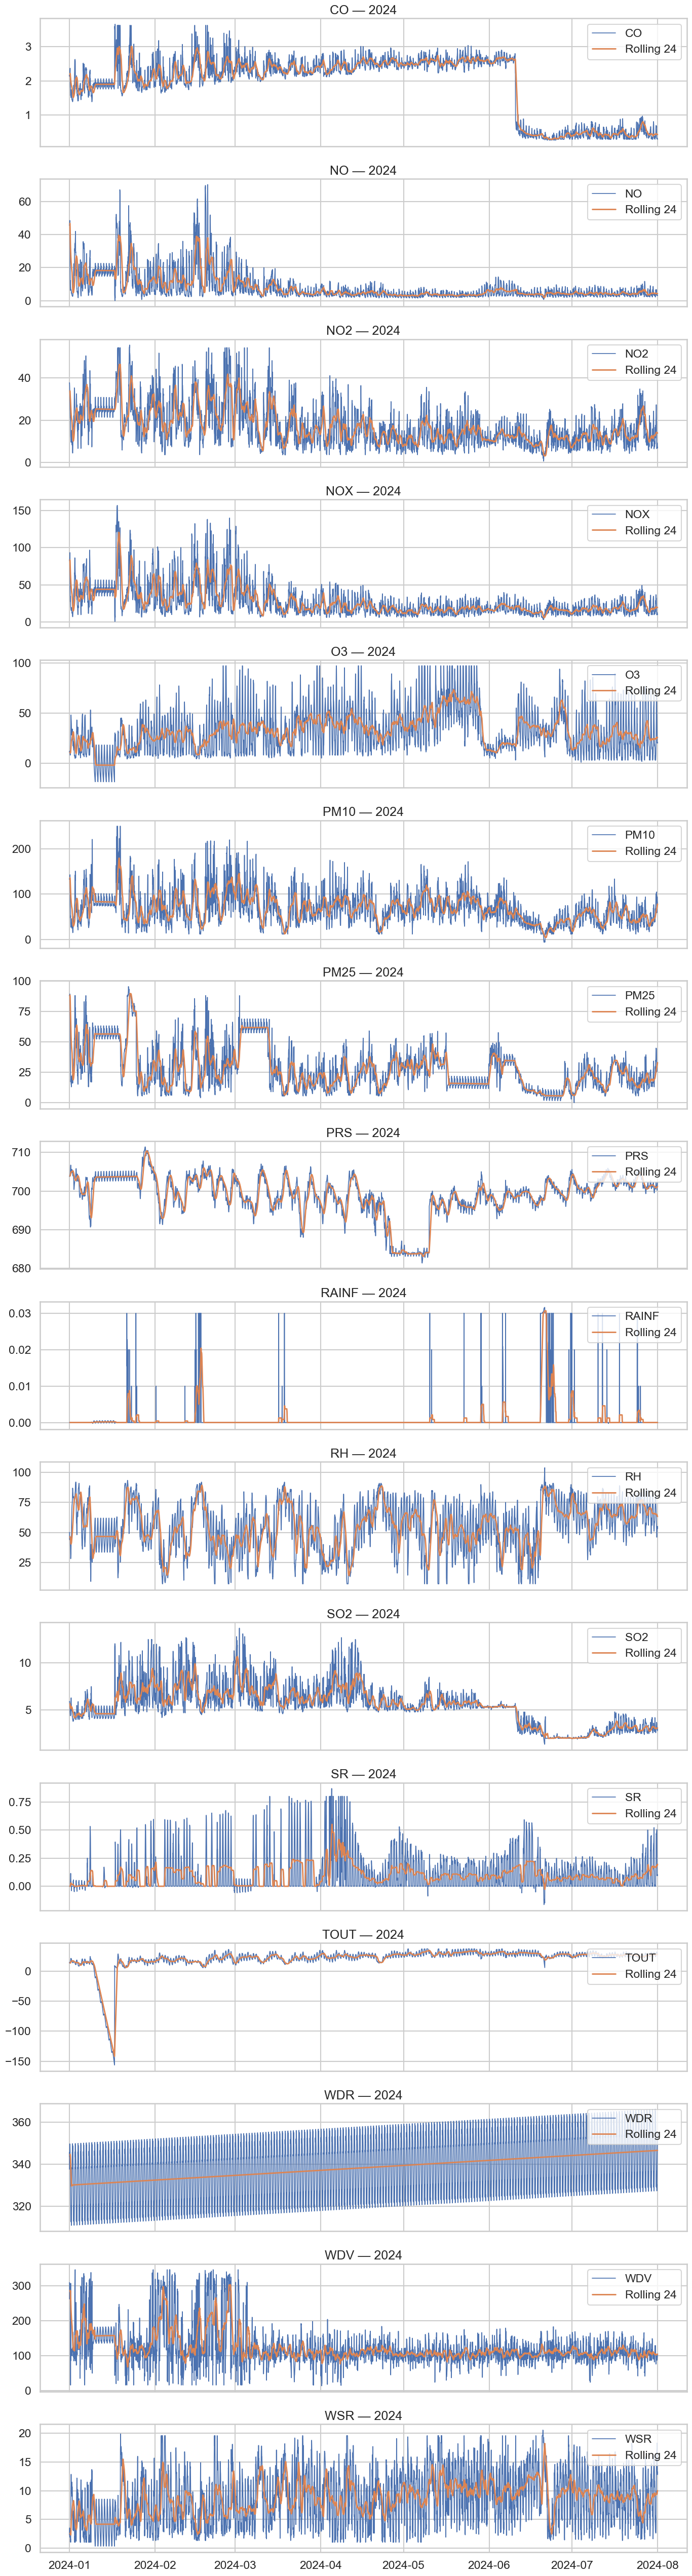

In [8]:
anio = 2024 

if station_col and estacion is not None:
    df_year = df_prep[(df_prep.index.year == anio) & (df_prep[station_col] == estacion)].copy()
else:
    df_year = df_prep[df_prep.index.year == anio].copy()

if resample_rule_year:
    df_plot = df_year.resample(resample_rule_year).mean(numeric_only=True)
else:
    df_plot = df_year

if df_plot.empty:
    print(f"No hay datos para {anio} (estación={estacion}).")
else:
    fig, axes = plt.subplots(len(pollutants), 1, figsize=(14, 3.2*len(pollutants)), sharex=True)
    axes = np.atleast_1d(axes)
    for ax, c in zip(axes, pollutants):
        if c not in df_plot.columns: 
            ax.set_visible(False); continue
        ax.plot(df_plot.index, df_plot[c], lw=1.2, label=c.upper())
        ax.plot(df_plot.index, df_plot[c].rolling(rolling_win, min_periods=max(2, rolling_win//4)).mean(),
                lw=2, label=f"Rolling {rolling_win}")
        title = f"{c.upper()} — {anio}" + (f" — Estación: {estacion}" if estacion else "")
        ax.set_title(title); ax.legend(loc="upper right")
    plt.tight_layout(); plt.show()


### Distribuciones y boxplots mensuales

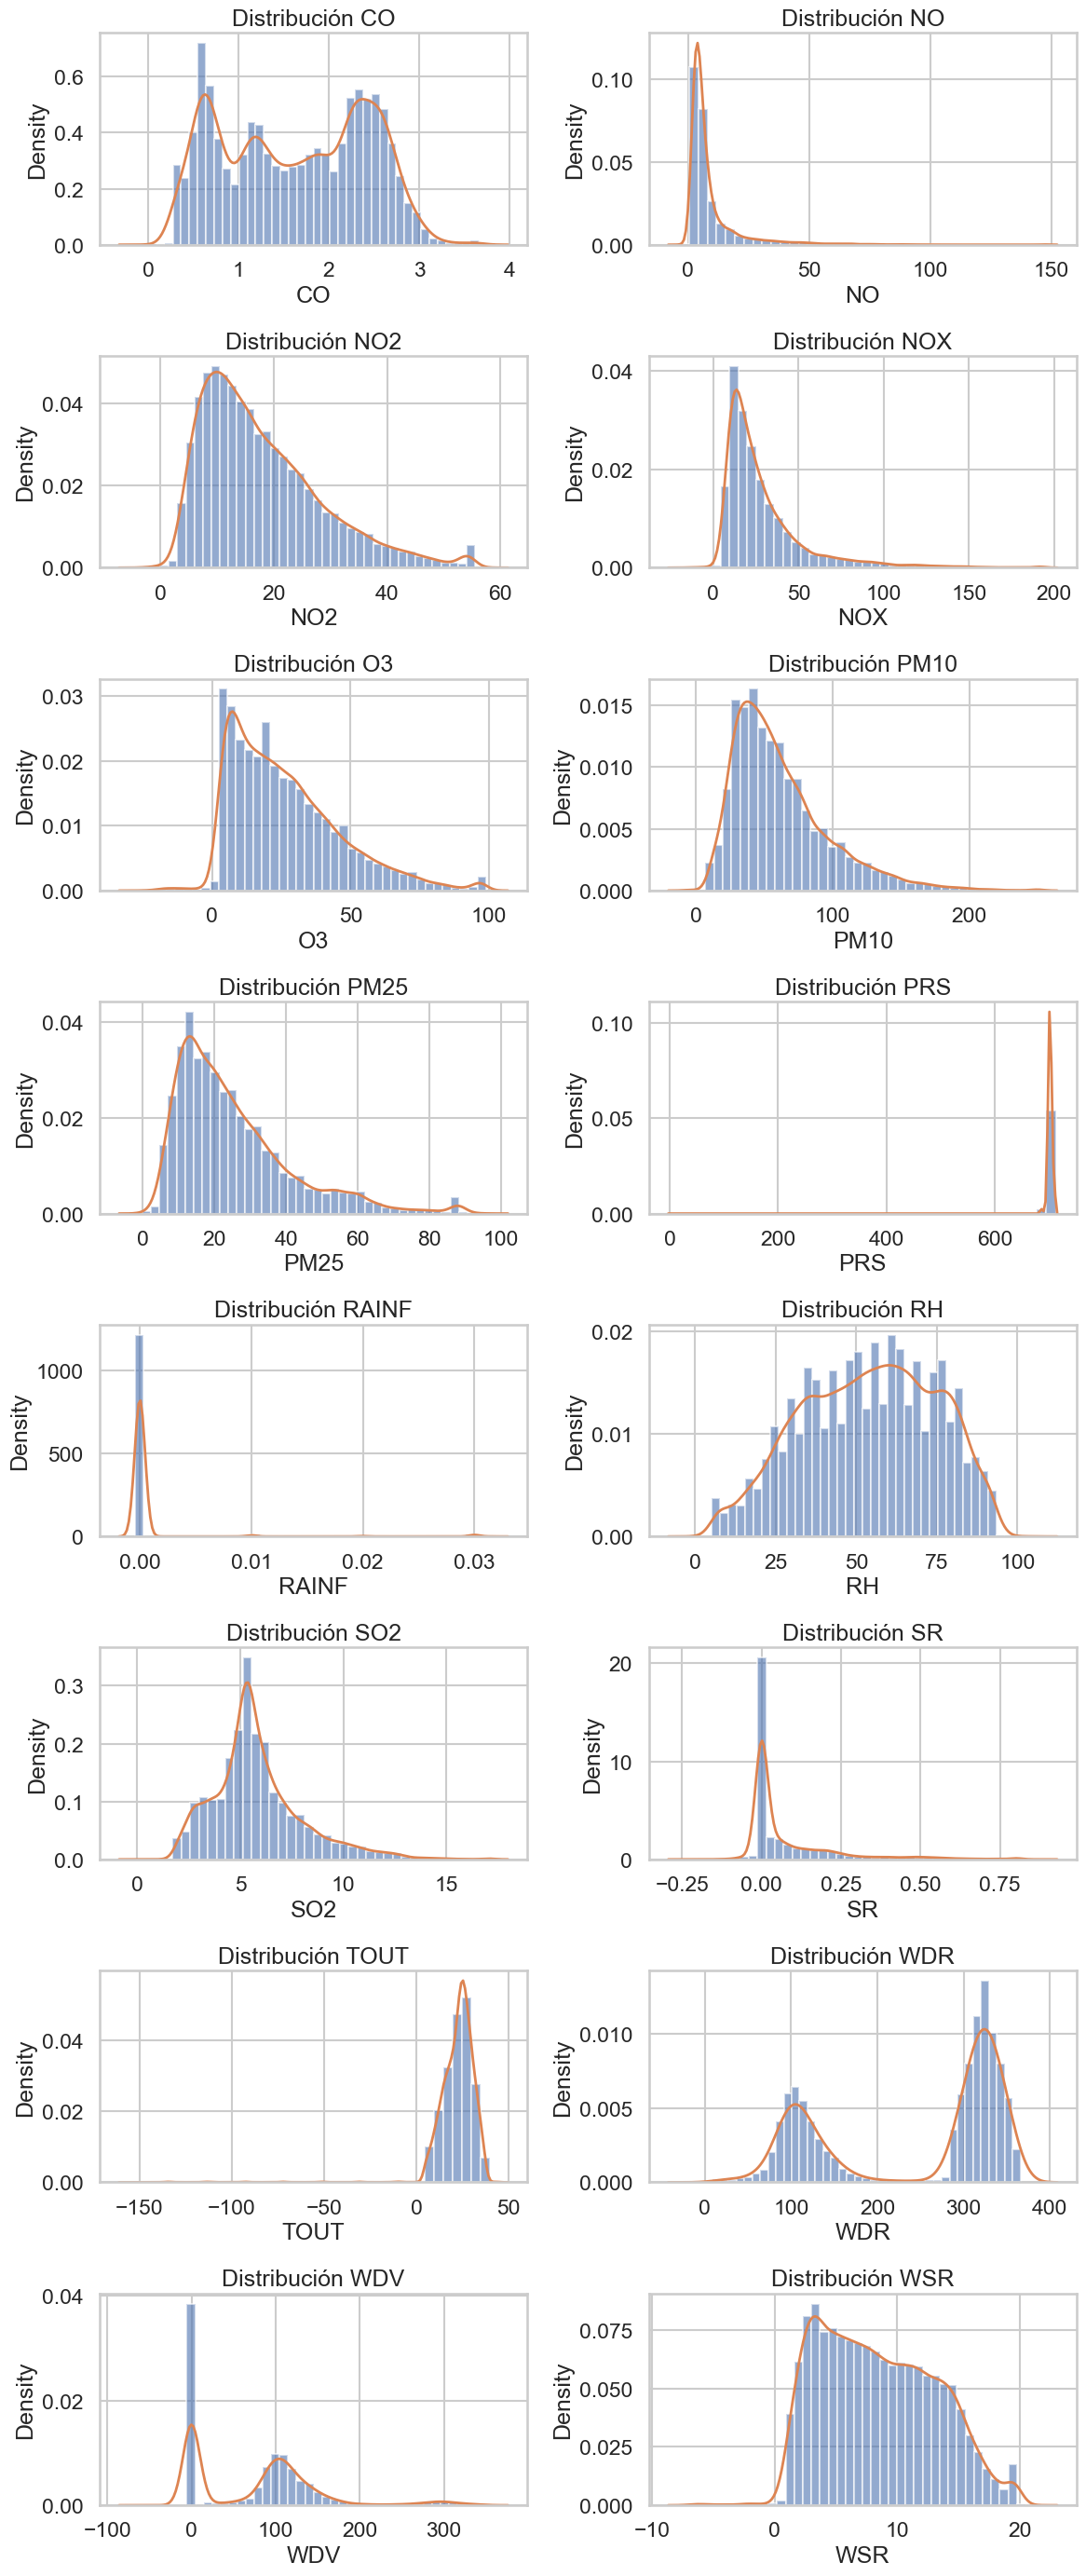

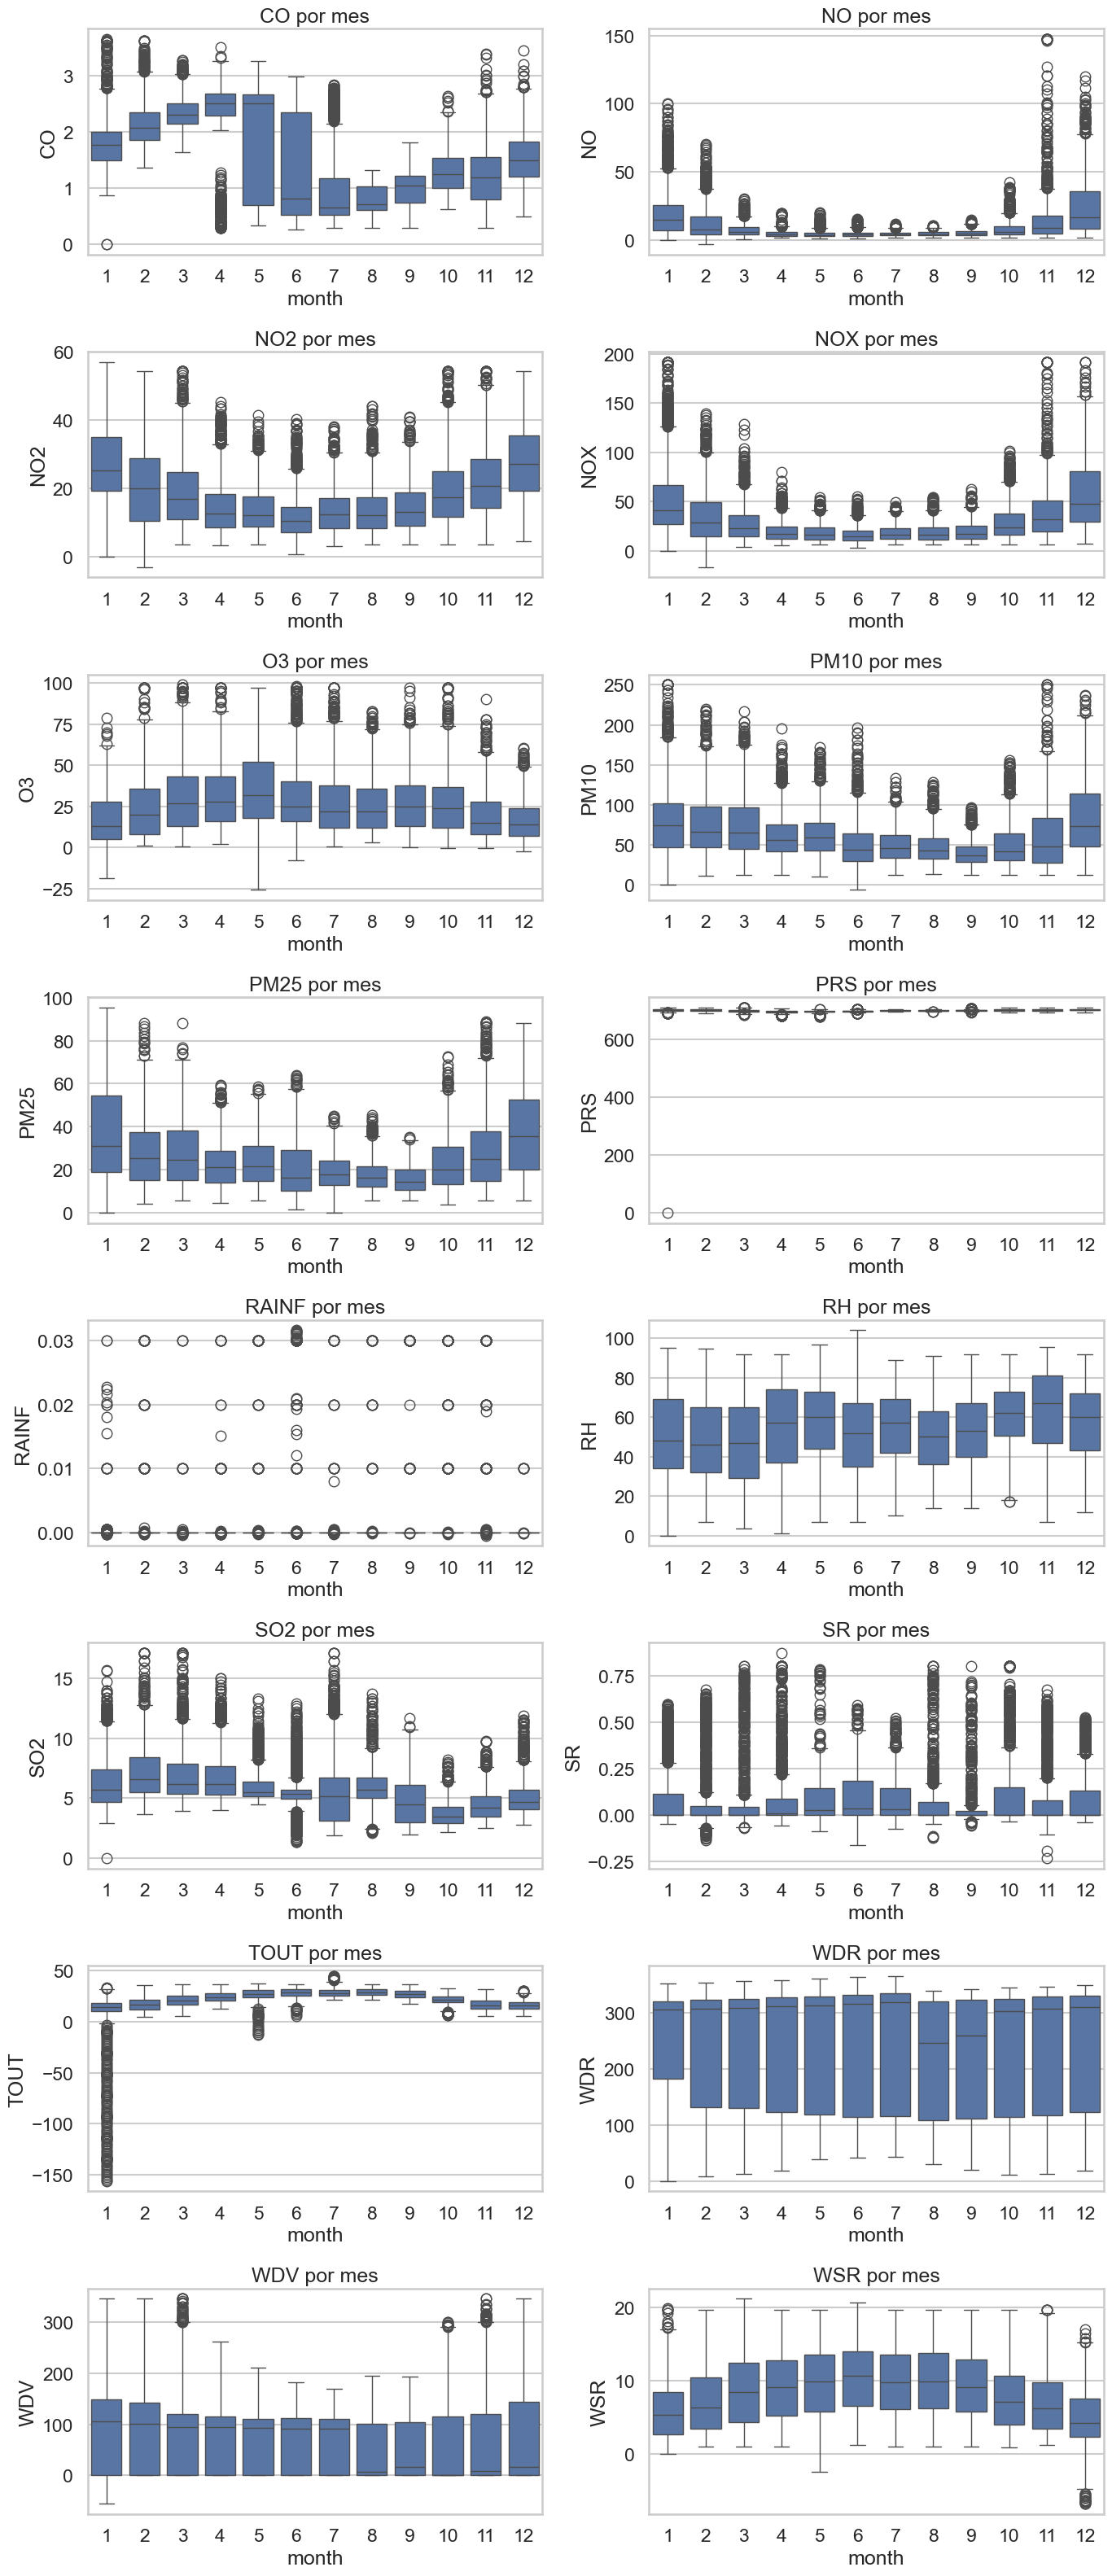

In [9]:
n = len(pollutants); ncols = 2 if n>1 else 1; nrows = int(np.ceil(n/ncols))
subt = ""
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.5*nrows)); axes = np.array(axes).reshape(-1)
for ax, c in zip(axes, pollutants):
    s = df_prep[c].dropna()
    ax.hist(s, bins=40, alpha=0.6, density=True)
    sns.kdeplot(s, ax=ax, lw=2)
    ax.set_title(f"Distribución {c.upper()}")
for ax in axes[len(pollutants):]: ax.set_visible(False)
plt.tight_layout(); plt.show()

x = df_prep.copy()
x["month"] = x.index.month
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4*nrows)); axes = np.array(axes).reshape(-1)
for ax, c in zip(axes, pollutants):
    sns.boxplot(data=x, x="month", y=c, ax=ax)
    ax.set_title(f"{c.upper()} por mes{subt}")
for ax in axes[len(pollutants):]: ax.set_visible(False)
plt.tight_layout(); plt.show()